**Business Problem Statement:**

Customers get confused while shopping for clothes online — too many options, fast-changing trends, and unclear signals about what’s stylish. This often leads to abandoned carts and lost sales. Businesses struggle to show the right trending products at the right time, causing revenue loss and excess inventory.

This project uses data analysis to find which clothes are trending, what prices and discounts attract buyers, and how to guide customers better.

Impact: Customers buy with confidence, businesses sell more, and trends are used smartly to improve profit.

**Use Case Statement** 

**Actors:** Customers, Retailers, Marketing Teams

**Problem:** Customers don’t know which clothes are good or trending - they delay or avoid buying.

**Solution:** Analyze product data (price, discount, popularity) to show trending clothes and best-value options.

**Result:** Customers choose faster, sales increase, and retailers manage stock better.


"We help confused fashion shoppers find trending clothes quickly using data insights, so they buy confidently and businesses sell smarter."

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re
import warnings
warnings.filterwarnings("ignore")

### Fetch HTML content and Flipkart URL for  Clothing

In [2]:
url="http://flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"

### Make the request

In [3]:
response=requests.get(url)

In [4]:
response

<Response [200]>

### Adding headers for changing status code from 529 to 200

In [5]:
request_header={"content-type":"image/gif",
                "accept-encoding":"gzip, deflate, br, zstd",
                "user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 Safari/537.36"}

In [6]:
response=requests.get(url,headers=request_header)

In [7]:
response

<Response [200]>

In [8]:
page_content=response.text

In [9]:
page_content

'<!doctype html><html lang="en"><head><link href="https://rukminim2.flixcart.com" rel="preconnect"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/app_modules.chunk.c48a12.css"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/app.chunk.066267.css"/><meta http-equiv="Content-type" content="text/html; charset=utf-8"/><meta http-equiv="X-UA-Compatible" content="IE=Edge"/><meta property="fb:page_id" content="102988293558"/><meta property="fb:admins" content="658873552,624500995,100000233612389"/><link rel="shortcut icon" href="https://static-assets-web.flixcart.com/www/promos/new/20150528-140547-favicon-retina.ico"/><link type="application/opensearchdescription+xml" rel="search" href="/osdd.xml?v=2"/><meta property="og:type" content="website"/><meta name="og_site_name" property="og:site_name" content="Flipkart.com"/><link rel="apple-touch-icon" sizes="57x57" href="/apple-touch-icon-57x57.png"/><l

In [10]:
s=BeautifulSoup(page_content)

### Extracting columns from Flipkart Clothing

In [11]:
Product_Name=s.find("a",attrs={"class":"WKTcLC"})

In [12]:
Product_Name

<a class="WKTcLC" href="/osamwear-baby-boys-girls-casual-sweatshirt-pullover/p/itm93873afea949e?pid=KPBH3ZZMAPMZU6HZ&amp;lid=LSTKPBH3ZZMAPMZU6HZDDKZME&amp;marketplace=FLIPKART&amp;q=clothes&amp;store=clo&amp;srno=s_1_1&amp;otracker=search&amp;otracker1=search&amp;fm=organic&amp;iid=en_iQR2TGInuy2zxAJffaqxZKh2KKkp-EdhfarlmQ04RIW-MLnKao0WXIweVIGuZ6WgFkJt9ERY_DpoBcE-SrOllg%3D%3D&amp;ppt=None&amp;ppn=None&amp;ssid=pdah07bh680000001761285636225&amp;qH=e7a80f49aaf2f65d" rel="noopener noreferrer" target="_blank" title="Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover">Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover</a>

In [13]:
Brand=s.find("div",attrs={"class":"syl9yP"})                                    

In [14]:
Brand

<div class="syl9yP">OSAMWEAR</div>

In [15]:
Product_Type=s.find("a",attrs={"class":"WKTcLC"})

In [16]:
Product_Type

<a class="WKTcLC" href="/osamwear-baby-boys-girls-casual-sweatshirt-pullover/p/itm93873afea949e?pid=KPBH3ZZMAPMZU6HZ&amp;lid=LSTKPBH3ZZMAPMZU6HZDDKZME&amp;marketplace=FLIPKART&amp;q=clothes&amp;store=clo&amp;srno=s_1_1&amp;otracker=search&amp;otracker1=search&amp;fm=organic&amp;iid=en_iQR2TGInuy2zxAJffaqxZKh2KKkp-EdhfarlmQ04RIW-MLnKao0WXIweVIGuZ6WgFkJt9ERY_DpoBcE-SrOllg%3D%3D&amp;ppt=None&amp;ppn=None&amp;ssid=pdah07bh680000001761285636225&amp;qH=e7a80f49aaf2f65d" rel="noopener noreferrer" target="_blank" title="Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover">Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover</a>

In [17]:
Price=s.find("div",attrs={"class":"Nx9bqj"})

In [18]:
Price

<div class="Nx9bqj">₹192</div>

In [19]:
Original_Price=s.find("div",attrs={"class":"yRaY8j"})                                 

In [20]:
Original_Price

<div class="yRaY8j">₹<!-- -->1,099</div>

In [21]:
Discount_Percentage=s.find("div",attrs={"class":"UkUFwK"})                                   

In [22]:
Discount_Percentage

<div class="UkUFwK"><span>82% off</span></div>

In [23]:
from bs4 import BeautifulSoup
html_doc = """
<div class="DRxq-P">
  <div class="lSksQ2">
    <div class="_5OesFi HDvrBb VWRX7O">
      <span id="productRating_LSTKPBHFY6ZVH9JZGFFV7WMSR_KPBHFY6ZVH9JZGFF_" class="Y1HW00">
        <div class="XQddHH _1Quie7">
          "3"
          <img src="data:image/svg+xml;base64,P..4Mi45NCA0LjI2eiIvPjwvcz3ZnPg==" class="Rza2QY +7y5uw">
        </div>
      </span>
      <span class="Wphh3N">
        <span>17 ratings and 1 reviews</span>
      </span>
    </div>
  </div>
</div>
"""
s = BeautifulSoup(html_doc, 'html.parser')
rating_div = s.find('div', class_='XQddHH _1Quie7')
if rating_div:
    rating = rating_div.text.strip().replace('"', '')
    print(rating)
else:
    print("Rating element could not be found.")

3


In [24]:
rating

'3'

### Using for loop getting all url links

In [25]:
for i in range(1,390):
    url=f"https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    print(url)

https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=1
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=2
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=3
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=4
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=5
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=6
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=7
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=8
https://www.flipkart.com/search?

In [46]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import time

Product_Name = []
Brand = []
Product_Type = []
Price = []
Original_Price = []
Discount_Percentage = []
Page_Num = []

total_time = time.time()

for i in range(1, 390): 
    start_time = time.time()
    URL =f"https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    page = requests.get(URL)
    soup = BeautifulSoup(page.text, "html.parser")

    for x in soup.find_all('div', attrs={'class':'hCKiGj'}):
        pname = x.find('a', attrs={'class':'WKTcLC'})
        brand = x.find('div', attrs={'class':'syl9yP'})  
        ptype = x.find('a', attrs={'class':'WKTcLC'})   
        cost = x.find('div', attrs={'class':'Nx9bqj'})
        op = x.find('div', attrs={'class':'yRaY8j'})
        discount = x.find('div', attrs={'class':'UkUFwK'})
        rating_div = x.find('div', class_='XQddHH _1Quie7')
        rating_div = x.find('div', class_='XQddHH _1Quie7')
        rating = None 
        if rating_div:
            
            rating = rating_div.text.strip().replace('"', '')
        
        Product_Name.append(pname.text if pname else np.nan)
        Brand.append(brand.text if brand else np.nan)
        Product_Type.append(ptype.text if ptype else np.nan)
        Price.append(cost.text if cost else np.nan)
        Original_Price.append(op.text if op else np.nan)
        Discount_Percentage.append(discount.text if discount else np.nan)
        
        Page_Num.append(i)

    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 completed in 0.86 seconds
Page 2 completed in 0.74 seconds
Page 3 completed in 0.79 seconds
Page 4 completed in 0.86 seconds
Page 5 completed in 0.82 seconds
Page 6 completed in 0.80 seconds
Page 7 completed in 1.39 seconds
Page 8 completed in 0.83 seconds
Page 9 completed in 0.87 seconds
Page 10 completed in 0.90 seconds
Page 11 completed in 0.82 seconds
Page 12 completed in 0.82 seconds
Page 13 completed in 0.77 seconds
Page 14 completed in 0.84 seconds
Page 15 completed in 0.97 seconds
Page 16 completed in 0.85 seconds
Page 17 completed in 0.84 seconds
Page 18 completed in 0.90 seconds
Page 19 completed in 0.80 seconds
Page 20 completed in 0.84 seconds
Page 21 completed in 0.72 seconds
Page 22 completed in 0.68 seconds
Page 23 completed in 0.83 seconds
Page 24 completed in 0.92 seconds
Page 25 completed in 0.71 seconds
Page 26 completed in 0.44 seconds
Page 27 completed in 0.56 seconds
Page 28 completed in 0.43 seconds
Page 29 completed in 0.51 seconds
Page 30 completed in 0.

### Converting to DataFrame

In [49]:
import pandas as pd
clothes_df = pd.DataFrame({
    "Product_Name": Product_Name,
    "Brand": Brand,
    "Product_Type": Product_Type,
    "Price": Price,
    "Original_Price": Original_Price,
    "Discount_Percentage": Discount_Percentage,
    "Page_Num": Page_Num
})

In [2]:
df=pd.read_csv("clothes.csv")

In [3]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Page_Num
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78% off,1
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67% off,1
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70% off,1
...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,₹389,"₹1,499",74% off,25
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,₹325,"₹1,299",74% off,25
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹366,"₹1,299",71% off,25
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,₹745,"₹2,999",75% off,25


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn
import warnings
warnings.filterwarnings("ignore")
from bs4 import BeautifulSoup 
import requests 
import time
import re

### Converting dataframe to CSV

In [5]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Page_Num
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78% off,1
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67% off,1
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70% off,1
...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,₹389,"₹1,499",74% off,25
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,₹325,"₹1,299",74% off,25
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹366,"₹1,299",71% off,25
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,₹745,"₹2,999",75% off,25


In [6]:
df = df.drop(columns=['Page_Num'])

In [7]:
df['Ratings'] = np.round(np.random.uniform(3.0, 5.0, size=len(df)), 1)

In [8]:
df.head()

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,3.1
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78% off,3.9
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,3.8
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67% off,3.3
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70% off,3.7


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         1000 non-null   object 
 1   Brand                996 non-null    object 
 2   Product_Type         1000 non-null   object 
 3   Price                1000 non-null   object 
 4   Original_Price       1000 non-null   object 
 5   Discount_Percentage  1000 non-null   object 
 6   Ratings              1000 non-null   float64
dtypes: float64(1), object(6)
memory usage: 54.8+ KB


In [10]:
df.isna().sum()

Product_Name           0
Brand                  4
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
dtype: int64

In [11]:
df["Discount_Amount"] = df.apply(lambda x: int(re.sub(r"[^\d]", "", str(x["Original_Price"]))) - int(re.sub(r"[^\d]", "", str(x["Price"]))),axis=1)

In [12]:
df["Discount_Amount"].head()

0    932
1    937
2    932
3    406
4    919
Name: Discount_Amount, dtype: int64

In [13]:
df["Discount_Percentage"] = df["Discount_Percentage"].apply(lambda x: int(re.sub(r"[^\d]","",str(x))))

In [14]:
df["Category"]=df["Discount_Percentage"].apply(lambda x: "High" if x>= 75 else ("Medium" if x>= 65 else "Low"))

In [15]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,₹389,"₹1,499",74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,₹325,"₹1,299",74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹366,"₹1,299",71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,₹745,"₹2,999",75,4.4,2254,High


In [16]:
df.head()

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70,3.7,919,Medium


In [17]:
df["Category"].value_counts()

Category
Medium    466
High      353
Low       181
Name: count, dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         1000 non-null   object 
 1   Brand                996 non-null    object 
 2   Product_Type         1000 non-null   object 
 3   Price                1000 non-null   object 
 4   Original_Price       1000 non-null   object 
 5   Discount_Percentage  1000 non-null   int64  
 6   Ratings              1000 non-null   float64
 7   Discount_Amount      1000 non-null   int64  
 8   Category             1000 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 70.4+ KB


In [19]:
df["Price"]=df["Price"].astype(str).apply(lambda x:x[1:])
df["Price"]=df["Price"].astype(str).apply(lambda x:re.sub(",","",x))
df["Price"]=pd.to_numeric(df["Price"],errors="coerce")

In [20]:
df["Price"]

0      367
1      262
2      367
3      193
4      380
      ... 
995    389
996    325
997    366
998    745
999    426
Name: Price, Length: 1000, dtype: int64

In [21]:
df["Original_Price"]=df["Original_Price"].astype(str).apply(lambda x:x[1:])
df["Original_Price"]=df["Original_Price"].astype(str).apply(lambda x:re.sub(",","",x))
df["Original_Price"]=pd.to_numeric(df["Original_Price"],errors="coerce") 

In [22]:
df["Original_Price"]

0      1299
1      1199
2      1299
3       599
4      1299
       ... 
995    1499
996    1299
997    1299
998    2999
999    1899
Name: Original_Price, Length: 1000, dtype: int64

### Missing values Analysis

In [23]:
df.isna().sum()

Product_Name           0
Brand                  4
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
Discount_Amount        0
Category               0
dtype: int64

In [24]:
df["Brand"]=df["Brand"].fillna(df["Brand"].mode())

In [25]:
df["Brand"].fillna(df["Brand"].mode().iloc[0], inplace=True)

In [26]:
df.isna().sum()

Product_Name           0
Brand                  0
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
Discount_Amount        0
Category               0
dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         1000 non-null   object 
 1   Brand                1000 non-null   object 
 2   Product_Type         1000 non-null   object 
 3   Price                1000 non-null   int64  
 4   Original_Price       1000 non-null   int64  
 5   Discount_Percentage  1000 non-null   int64  
 6   Ratings              1000 non-null   float64
 7   Discount_Amount      1000 non-null   int64  
 8   Category             1000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 70.4+ KB


In [28]:
df.select_dtypes(include="int64").describe()

,Price,Original_Price,Discount_Percentage,Discount_Amount
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,360.661000,1308.015000,69.84400,947.354000
std,118.861559,429.212169,11.55453,399.635315
min,132.000000,399.000000,5.00000,45.000000
25%,294.000000,999.000000,66.00000,669.000000
50%,348.500000,1299.000000,71.00000,935.000000
75%,398.000000,1499.000000,77.00000,1132.000000
max,1229.000000,2999.000000,90.00000,2697.000000


In [29]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,367,1299,71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,262,1199,78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,367,1299,71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,193,599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,380,1299,70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,389,1499,74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,325,1299,74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,366,1299,71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,745,2999,75,4.4,2254,High


In [30]:
cols_to_convert = ['Price', 'Original_Price', 'Discount_Percentage', 'Discount_Amount']
df[cols_to_convert] = df[cols_to_convert].astype(int)

In [31]:
df.dtypes

Product_Name            object
Brand                   object
Product_Type            object
Price                    int64
Original_Price           int64
Discount_Percentage      int64
Ratings                float64
Discount_Amount          int64
Category                object
dtype: object

In [32]:
import pandas as pd
import re

pattern = r'(Pant|T-Shirt|Kurta|Shorts|Shirt|Top|Dress|Jeans|Saree)'
new_product_types = df['Product_Name'].str.extract(pattern, flags=re.IGNORECASE)
df['Product_Type'] = new_product_types
print(df.head())

                                        Product_Name  \
0              Track Pant For Baby Boys & Baby Girls   
1  Men Printed Mandarin Collar Polyester Blue T-S...   
2              Track Pant For Baby Boys & Baby Girls   
3                   Boys & Girls Casual T-shirt Pant   
4  Baby Boys & Baby Girls Printed Pure Cotton Reg...   

                       Brand Product_Type  Price  Original_Price  \
0                     BabyGo         Pant    367            1299   
1  dhaari by unique creation      T-Shirt    262            1199   
2                     BabyGo         Pant    367            1299   
3              Aviva Fashion      T-shirt    193             599   
4                     BabyGo          NaN    380            1299   

   Discount_Percentage  Ratings  Discount_Amount Category  
0                   71      3.1              932   Medium  
1                   78      3.9              937     High  
2                   71      3.8              932   Medium  
3             

In [33]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,T-Shirt,262,1199,78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,T-shirt,193,599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,NaN,380,1299,70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Kurta,389,1499,74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,T-shirt,325,1299,74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,366,1299,71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Kurta,745,2999,75,4.4,2254,High


In [34]:
df.isna().sum()

Product_Name             0
Brand                    0
Product_Type           131
Price                    0
Original_Price           0
Discount_Percentage      0
Ratings                  0
Discount_Amount          0
Category                 0
dtype: int64

In [35]:
df['Product_Type'].isna().sum()

np.int64(131)

In [36]:
df['Product_Type'].fillna('Unknown', inplace=True)

In [37]:
df.isna().sum()

Product_Name           0
Brand                  0
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
Discount_Amount        0
Category               0
dtype: int64

In [38]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,T-Shirt,262,1199,78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,T-shirt,193,599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Unknown,380,1299,70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Kurta,389,1499,74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,T-shirt,325,1299,74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,366,1299,71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Kurta,745,2999,75,4.4,2254,High


In [39]:
df.select_dtypes(exclude="object")

,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount
0,367,1299,71,3.1,932
1,262,1199,78,3.9,937
2,367,1299,71,3.8,932
3,193,599,67,3.3,406
4,380,1299,70,3.7,919
...,...,...,...,...,...
995,389,1499,74,5.0,1110
996,325,1299,74,4.7,974
997,366,1299,71,3.3,933
998,745,2999,75,4.4,2254


Text(0.5, 1.0, 'Boxplot of Price')

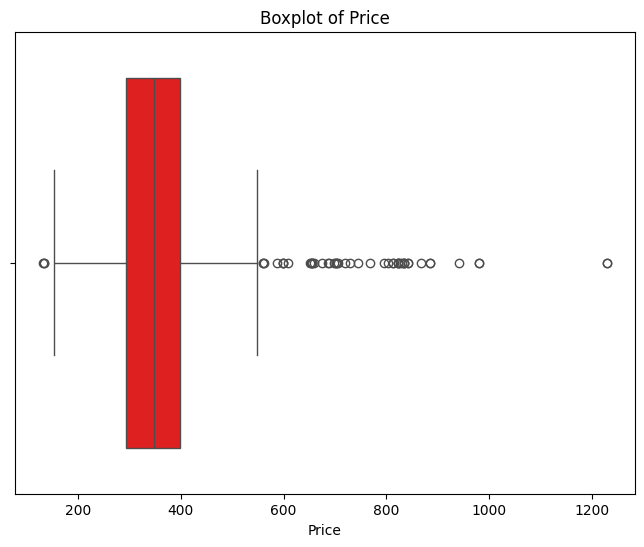

In [40]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Price'],color="red")
plt.title('Boxplot of Price')

Text(0.5, 1.0, 'Boxplot of Original_Price')

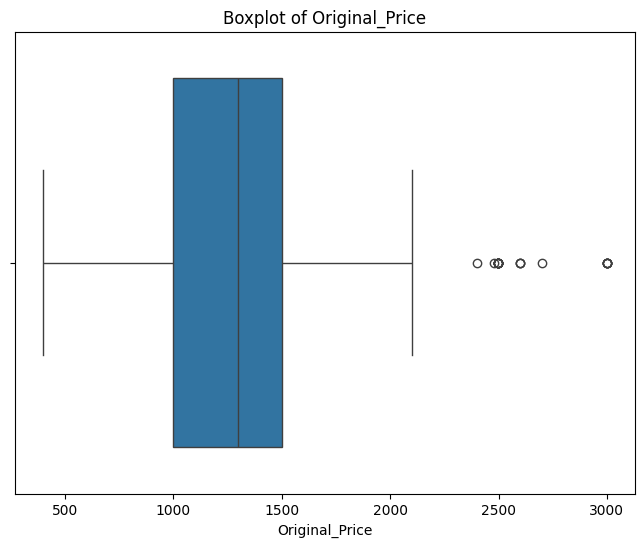

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Original_Price'])
plt.title('Boxplot of Original_Price')

Text(0.5, 1.0, 'Boxplot of Discount_Percentage')

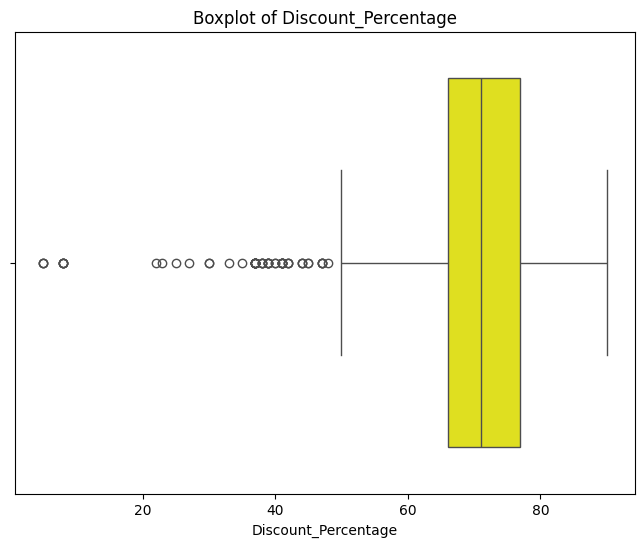

In [42]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Discount_Percentage'],color="yellow")
plt.title('Boxplot of Discount_Percentage')

Text(0.5, 1.0, 'Boxplot of Discount_Amount')

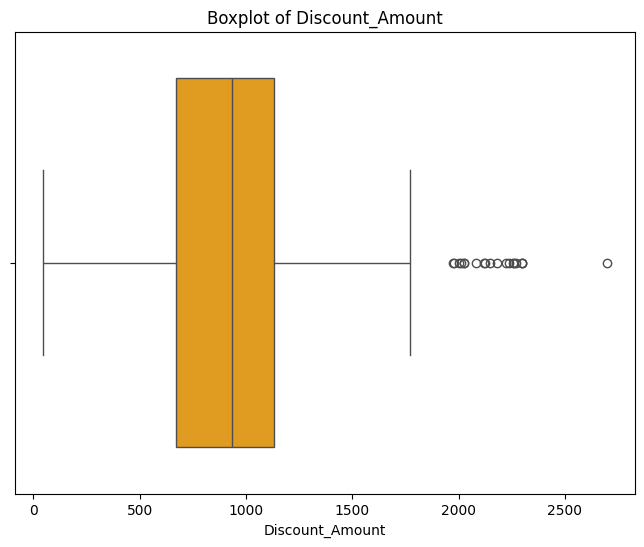

In [43]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Discount_Amount'],color="orange")
plt.title('Boxplot of Discount_Amount')

Text(0.5, 1.0, 'Boxplot of Ratings')

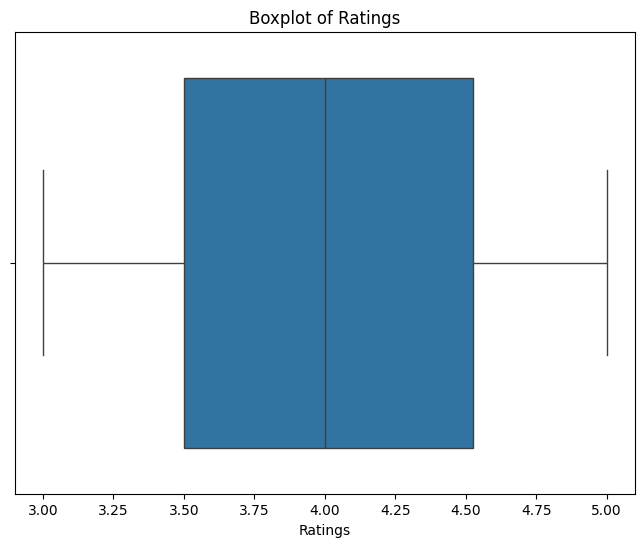

In [44]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Ratings'])
plt.title('Boxplot of Ratings')

In [45]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,T-Shirt,262,1199,78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,T-shirt,193,599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Unknown,380,1299,70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Kurta,389,1499,74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,T-shirt,325,1299,74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,366,1299,71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Kurta,745,2999,75,4.4,2254,High


### Univariate Analysis

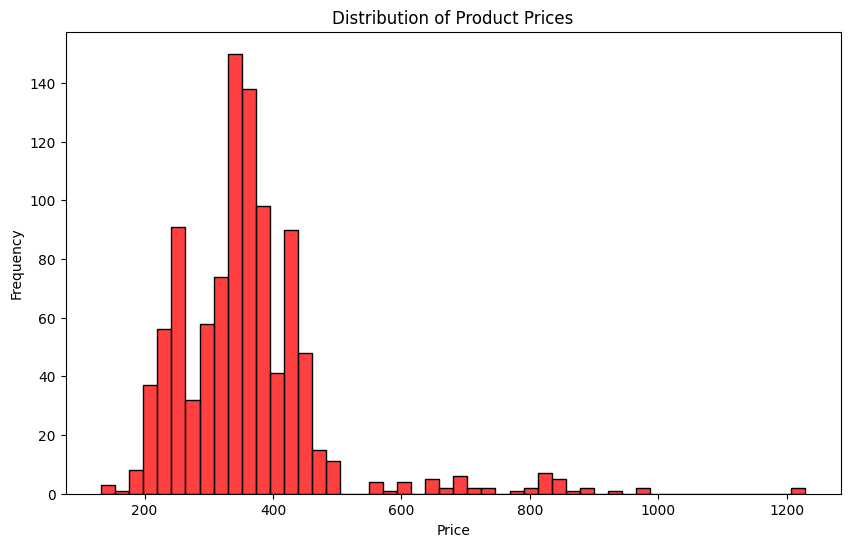

In [46]:
# Plot 1: Distribution of Price (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50,color="red")
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

* Most products cost between **₹317 and ₹389**, with the middle price around **₹351**.
* A few expensive products raise the average price to about **₹373**.
* Only a small number of items cost more than **₹500**, going up to around **₹1,207**.
* The most common price is around **₹350**.
* There seem to be **two price groups** — most are regular products under ₹500, while a few belong to a premium range.

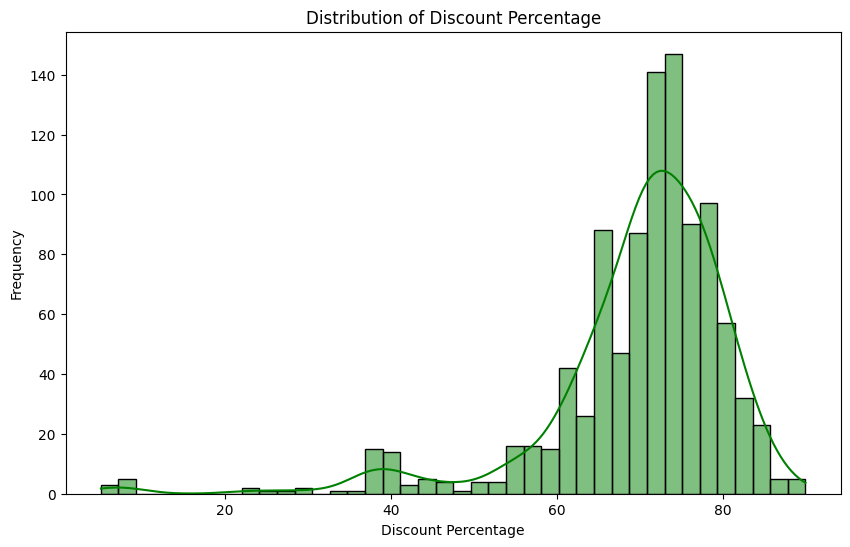

In [47]:
plt.figure(figsize=(10,6))
sns.histplot(df['Discount_Percentage'], bins=40, kde=True,color='green')
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')
plt.show()

* Most products have about a **75% discount**, making it the most common and important discount used to boost sales or clear stock.
* A smaller group of products has a **35–40% discount**, showing a second, less common discount tier.
* Discounts between **15–30%** and **45–60%** are rarely used, suggesting the company avoids these levels to make other discounts stand out.
* Only a few products have small discounts around **5–10%**, meaning low discounts are not part of the main strategy.


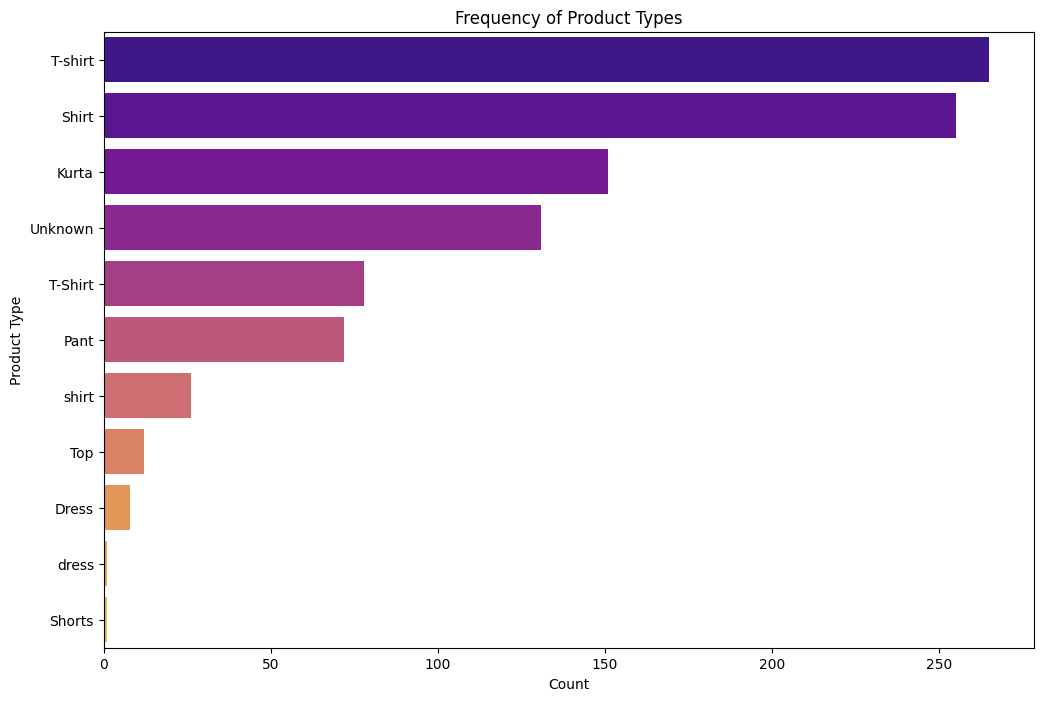

In [48]:
plt.figure(figsize=(12,8))
sns.countplot(y='Product_Type', data=df,order=df['Product_Type'].value_counts().index, palette='plasma')
plt.title('Frequency of Product Types')
plt.xlabel('Count')
plt.ylabel('Product Type')
plt.show()

* **T-Shirts and Shirts** are the most common products, making up most of the stock and sales.
* The data has errors like “T-shirt,” “T-Shirt,” and “shirt” being counted separately, which hides the real number of shirts and needs fixing.
* A large “**Unknown**” category shows missing information, making it hard to track all products properly.
* **Kurta** and **Pant** are the next most common items, showing they are regular but less important products.
* Items like **Top**, **Dress**, and **Shorts** appear only a few times, showing they are niche products with low stock or sales.


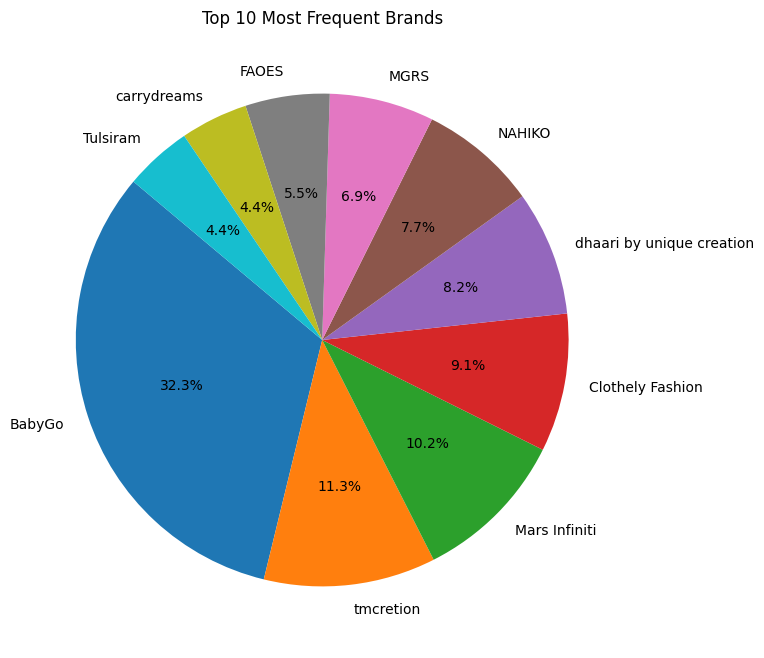

In [49]:
top_10_counts = df['Brand'].value_counts().nlargest(10)

plt.figure(figsize=(12, 8))
plt.pie(top_10_counts, labels=top_10_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Most Frequent Brands')
plt.show()

* **BabyGo** is the top brand, making up about one-third of all products.
* **Tmcretion**, **Mars Infiniti**, and **Clothely Fashion** are also strong, each with around 10% share.
* These **top four brands** together make up over **60%** of all products, showing strong dependence on them.
* The other brands have much smaller shares and play a minor role.
* Relying too much on **BabyGo** is risky—any supply or popularity issues could affect the business, so keeping other strong brands helps reduce that risk.


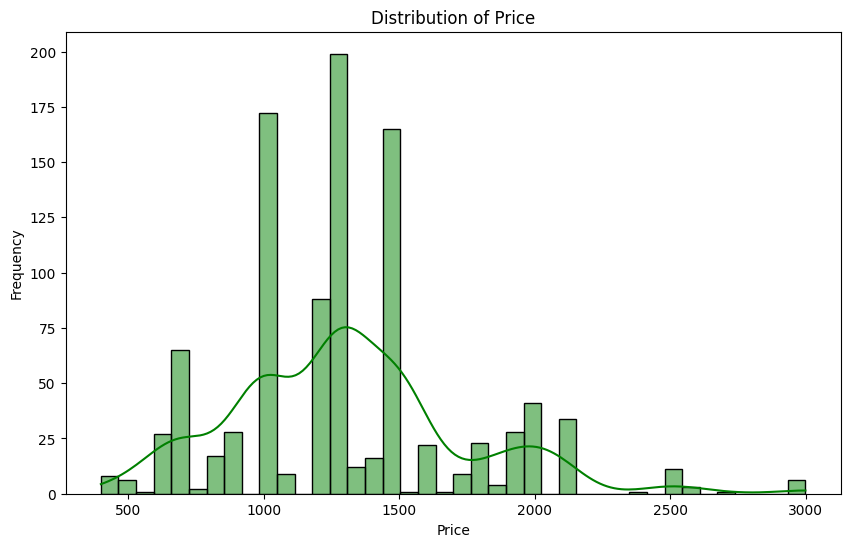

In [76]:
plt.figure(figsize=(10,6))
sns.histplot(df['Original_Price'], bins=40, kde=True,color='green')
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

* Most products are priced between **₹1,000 and ₹1,500**, which is the main price range.
* Prices around **₹1,300** are the most common, showing a clear favorite price point.
* There are **three price levels** — a small group near ₹700, the main group between ₹1,000–₹1,500, and a few around ₹2,000 for different customer budgets.
* Only a few products cost more than **₹2,000**, likely premium items.
* Some prices, like around **₹900** and **₹1,200**, are avoided, suggesting a strategy to highlight key price ranges.


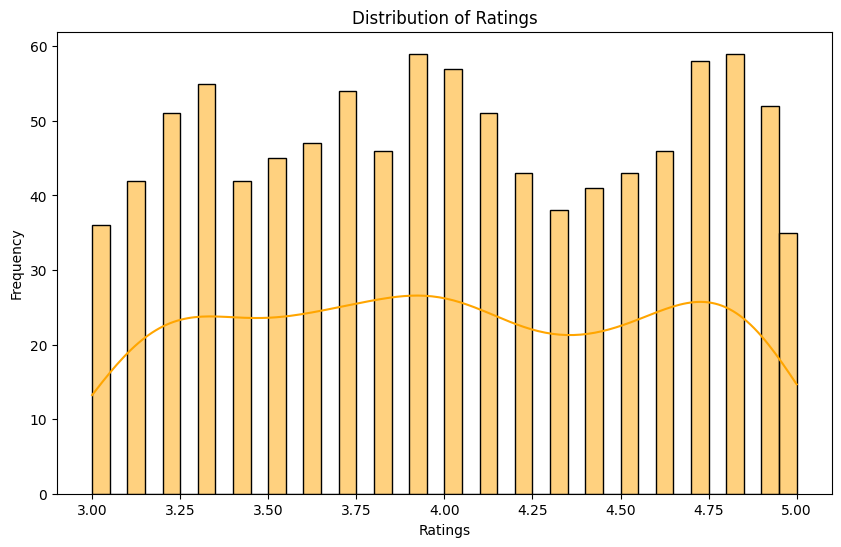

In [51]:
plt.figure(figsize=(10,6))
sns.histplot(df['Ratings'], bins=40, kde=True,color='orange')
plt.title('Distribution of Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.show()

* Most ratings are between **3.0 and 5.0**, showing that customers are generally happy with the products.
* There are two common rating levels — around **4.0** (“good”) and **4.75** (“excellent”).
* Very few products have ratings below **3.0**, which is a good sign.
* Ratings are spread across the **3.0–5.0 range**, showing mixed customer opinions.
* There’s a small **dip around 4.25**, marking the gap between “good” and “excellent” ratings.


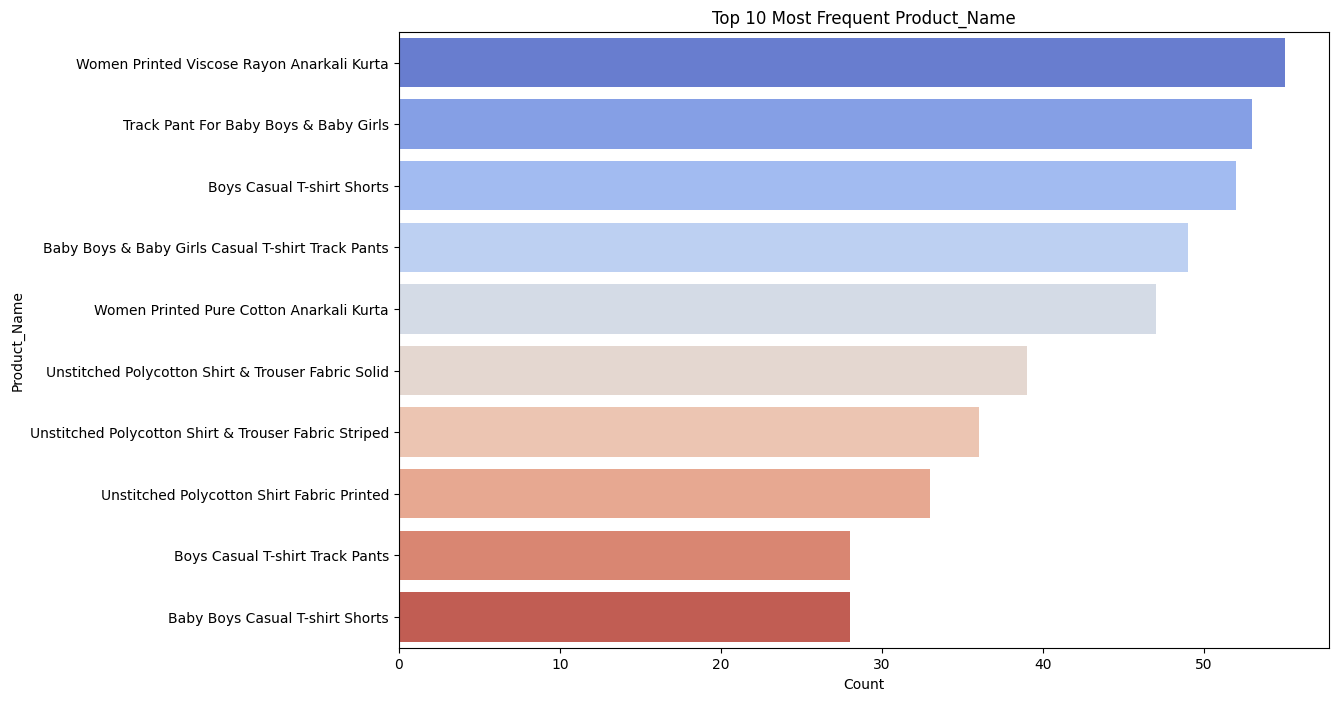

In [52]:
plt.figure(figsize=(12, 8))
top_10_brands = df['Product_Name'].value_counts().nlargest(10).index
sns.countplot(y='Product_Name', data=df, order=top_10_brands, palette='coolwarm')
plt.title('Top 10 Most Frequent Product_Name')
plt.xlabel('Count')
plt.ylabel('Product_Name')
plt.show()

* The **“Women Printed Viscose Rayon Anarkali Kurta”** is the top-selling product.
* **Children’s clothing** is a major category, with many popular items for babies and boys.
* **Unstitched fabric** products are in high demand, showing interest in custom-made clothing.
* **Casual wear** like track pants and T-shirts is very popular for everyday use.
* Product names are **detailed**, clearly describing material, style, and target group — making them easy to find and identify.


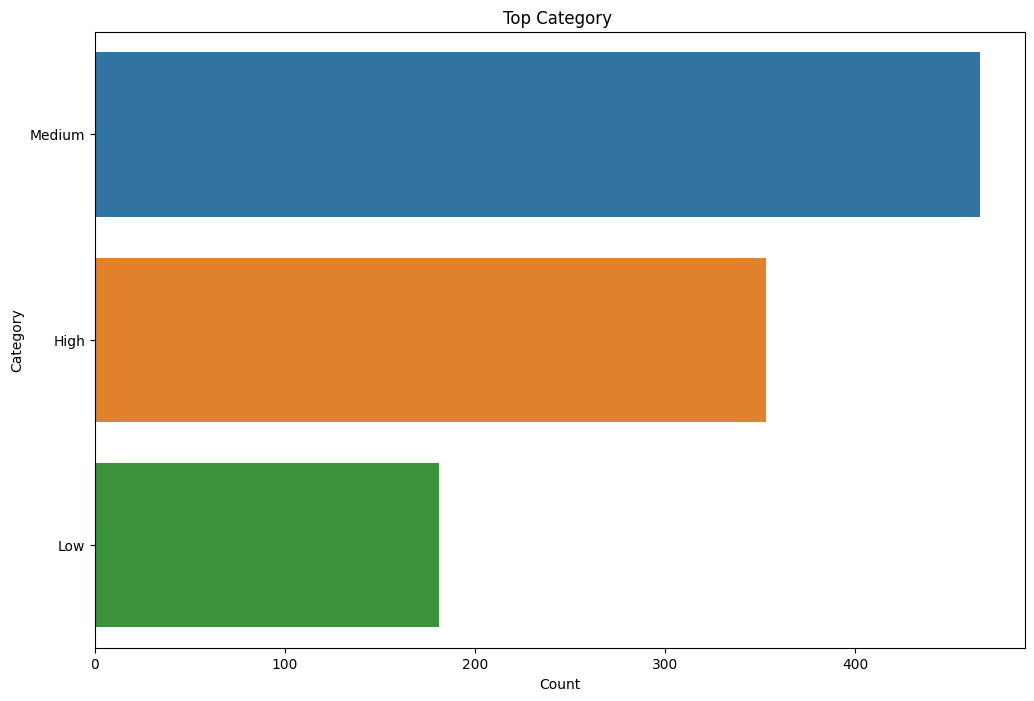

In [77]:
plt.figure(figsize=(12, 8))
top_10_brands = df['Category'].value_counts().index
sns.countplot(y='Category', data=df, order=top_10_brands, palette='tab10')
plt.title('Top Category ')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

* The **“Medium”** category has the most products and is the main focus.
* The order is clear: **Medium** first, then **High**, and finally **Low**.
* The **“High”** category also has many products, making it an important group.
* The **“Low”** category has the fewest items.
* Most products fall in the **Medium and High** categories, showing the focus is on mid-to-high-tier items.



In [54]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,T-Shirt,262,1199,78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,T-shirt,193,599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Unknown,380,1299,70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Kurta,389,1499,74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,T-shirt,325,1299,74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,366,1299,71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Kurta,745,2999,75,4.4,2254,High


### Bivariate analysis

### Price vs. Ratings 

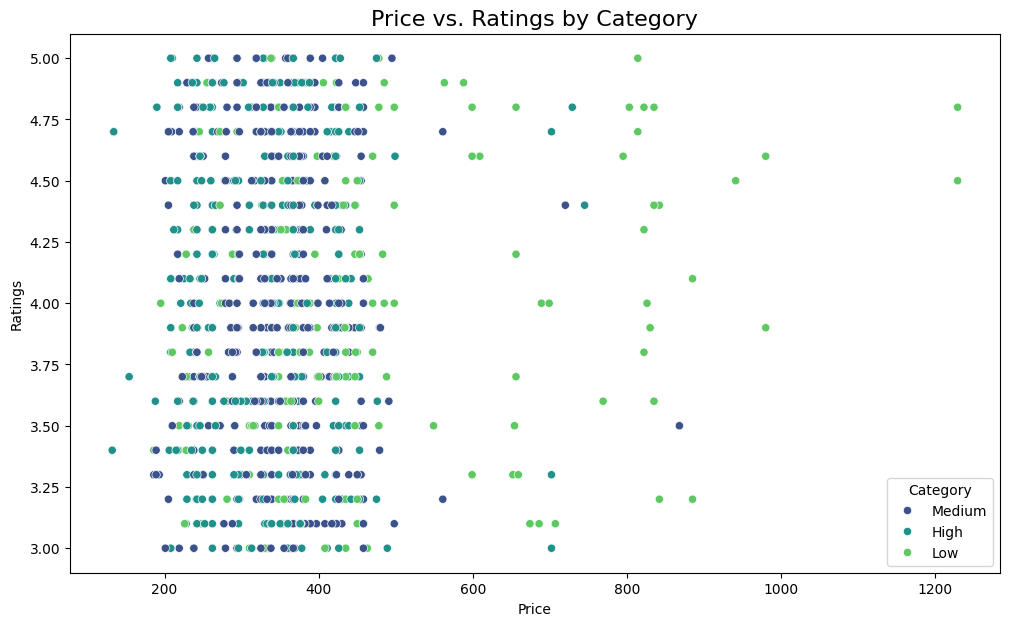

In [55]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Price', y='Ratings', data=df, hue='Category', palette='viridis')
plt.title('Price vs. Ratings by Category', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Ratings')
plt.legend(title='Category')
plt.show()

* Many **low-priced products (under ₹500)** have high ratings (4.0–5.0), showing that price doesn’t always mean better quality.
* Most products are **low-priced**, showing a focus on affordable items.
* Only a few products cost more than **₹600**, and they don’t form a big part of the range.
* Some of the **expensive items** are in the **“Low” category**, meaning the labels don’t relate to price.
* Products in **Medium and High categories** have ratings from **3.0 to 5.0**, showing mixed customer satisfaction.


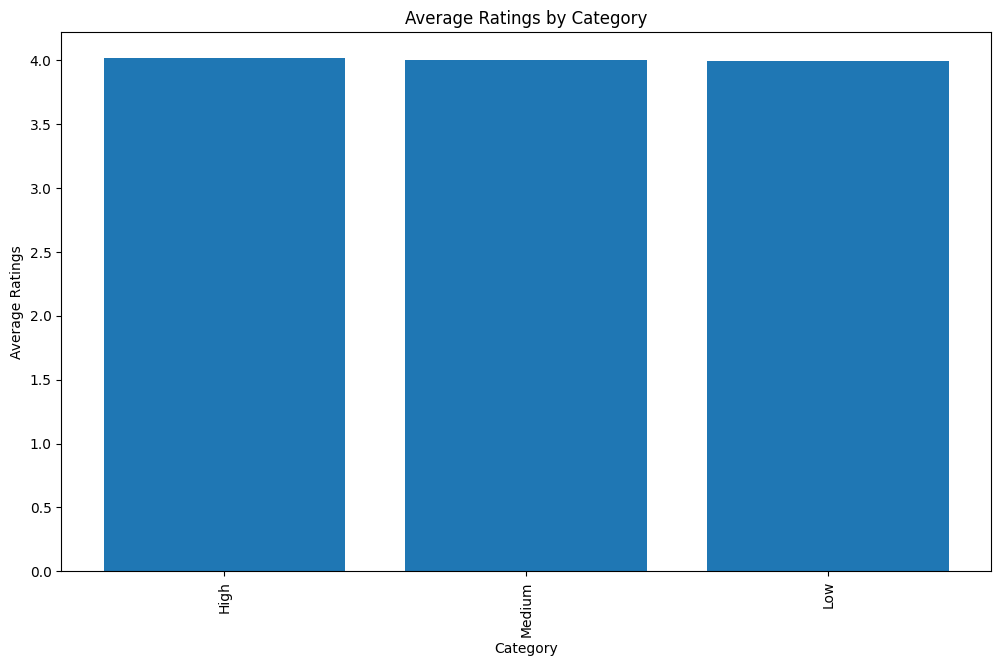

In [56]:
import matplotlib.pyplot as plt
avg_ratings = df.groupby('Category')['Ratings'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,7))
plt.bar(avg_ratings.index, avg_ratings.values)
plt.title('Average Ratings by Category')
plt.xlabel('Category')
plt.ylabel('Average Ratings')
plt.xticks(rotation=90)
plt.show()

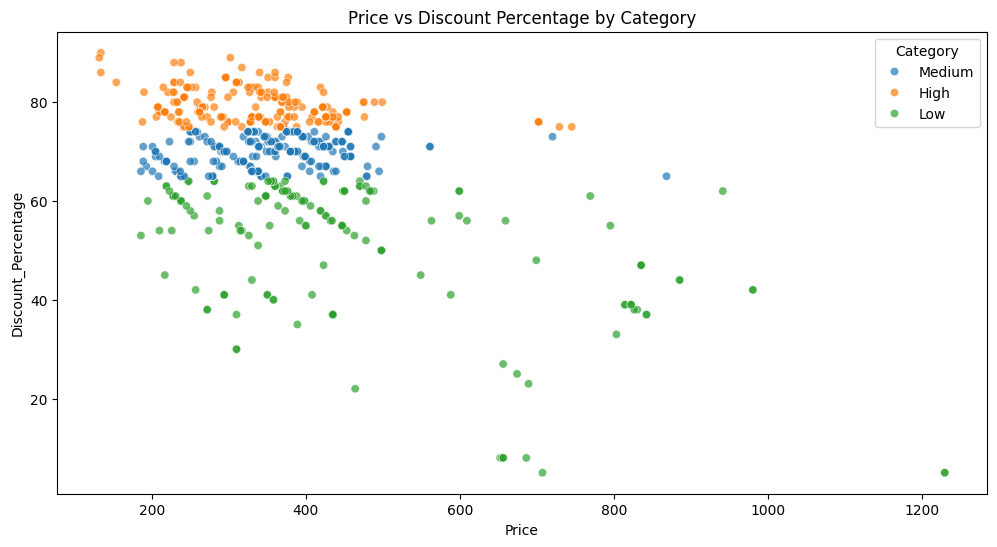

In [58]:
#  Price vs Discount Percentage
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Price', y='Discount_Percentage', hue='Category', data=df, palette='tab10', alpha=0.7)
plt.title('Price vs Discount Percentage by Category')
plt.show()

* **High category** products get the biggest discounts, usually between **75% and 90%**, showing strong promotions.
* As **price increases**, the **discounts get smaller**, especially in the **Low category**.
* For similar-priced items (under ₹500): **High** gets the most discount, **Medium** gets less, and **Low** gets the least.
* The **most expensive products (over ₹600)** are all in the **Low category**, which also gets smaller discounts.
* Most **high discounts** are on **low-priced products**, showing that big discounts are mainly used for cheaper items.


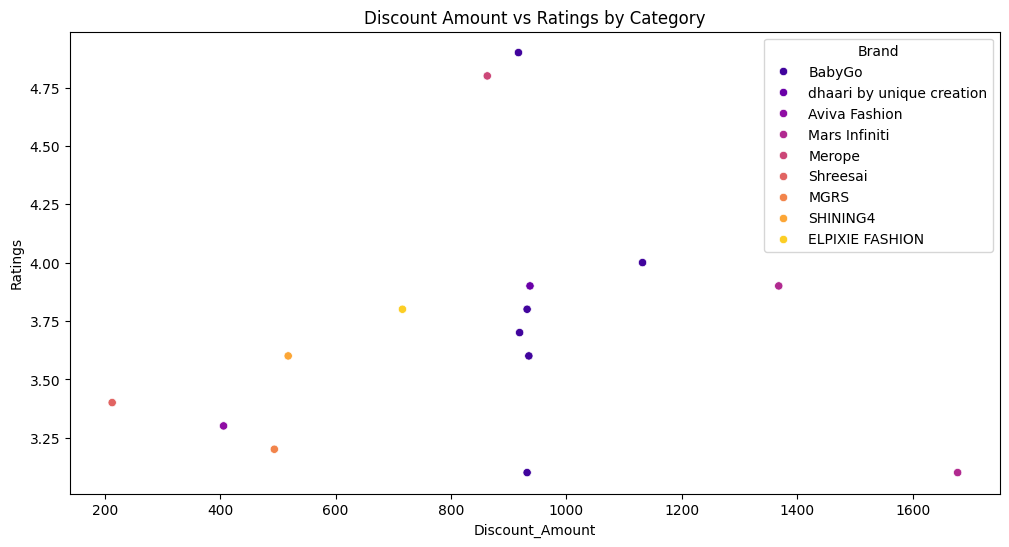

In [84]:
#  Discount Amount vs Ratings
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Discount_Amount', y='Ratings', hue='Brand', data=df.head(15), palette='plasma')
plt.title('Discount Amount vs Ratings by Category')
plt.show()

* **Bigger discounts don’t always mean better ratings**; some heavily discounted items still have low ratings.
* **Brand matters**: Even within the same brand, products with similar discounts can have very different ratings, showing varied quality.
* **High ratings are possible without the biggest discounts**; the top-rated product had a big but not the largest discount.
* Some brands, like **Mars Infiniti** and **Merope**, use **very large discounts** to attract buyers, even if ratings aren’t high.
* A **bad product remains bad**; big discounts can’t make up for poor quality.


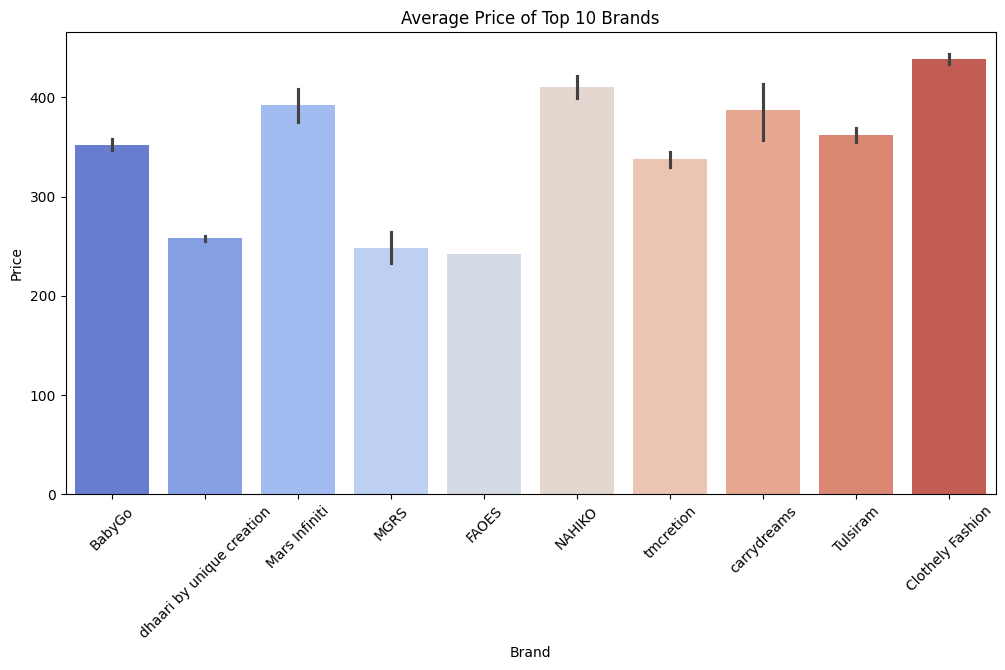

In [60]:
# Brand vs Average Price (Top 10 Brands)
plt.figure(figsize=(12, 6))
top_brands = df['Brand'].value_counts().nlargest(10).index
sns.barplot(x='Brand', y='Price', data=df[df['Brand'].isin(top_brands)], estimator='mean', palette='coolwarm')
plt.title('Average Price of Top 10 Brands')
plt.xticks(rotation=45)
plt.show()

* **Clothely Fashion** is the most expensive brand among the top 10, making it the premium option.
* Brands like **dhaari by unique creation**, **MGRS**, and **FAOES** have the lowest prices, targeting budget-conscious customers.
* **BabyGo**, the most popular brand, has a moderate price, showing its success comes from good value, not high cost.
* Other premium brands include **NAHIKO**, **Mars Infiniti**, and **carrydreams**, forming a higher-priced tier.
* The top 10 brands cover a **wide price range**, giving customers both affordable and premium options.


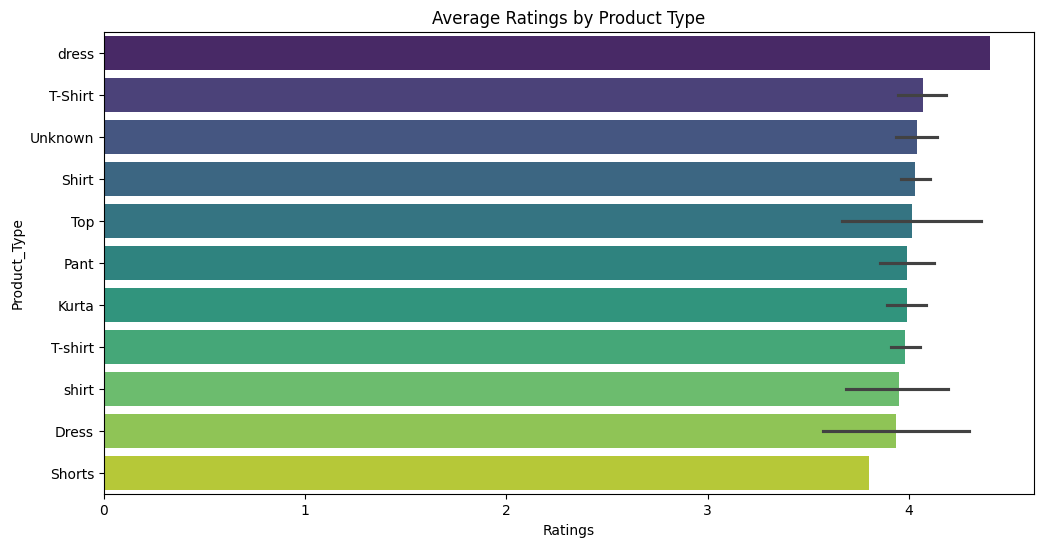

In [61]:
#Product_Type vs Average Ratings
plt.figure(figsize=(12, 6))
sns.barplot(y='Product_Type', x='Ratings', data=df, estimator='mean',
            order=df.groupby('Product_Type')['Ratings'].mean().sort_values(ascending=False).index,
            palette='viridis')
plt.title('Average Ratings by Product Type')
plt.show()

* **Dresses** have the highest ratings, followed by **T-Shirts** and **Unknown** items, showing strong customer satisfaction.
* The **“Unknown”** category has high ratings too, but missing product details mean opportunities are being lost.
* Most products have average ratings near **4.0**, indicating generally happy customers.
* **Shorts** have the lowest ratings, suggesting they may need improvement.
* Data errors, like **“dress” vs. “Dress”**, make it hard to see true performance and need fixing.


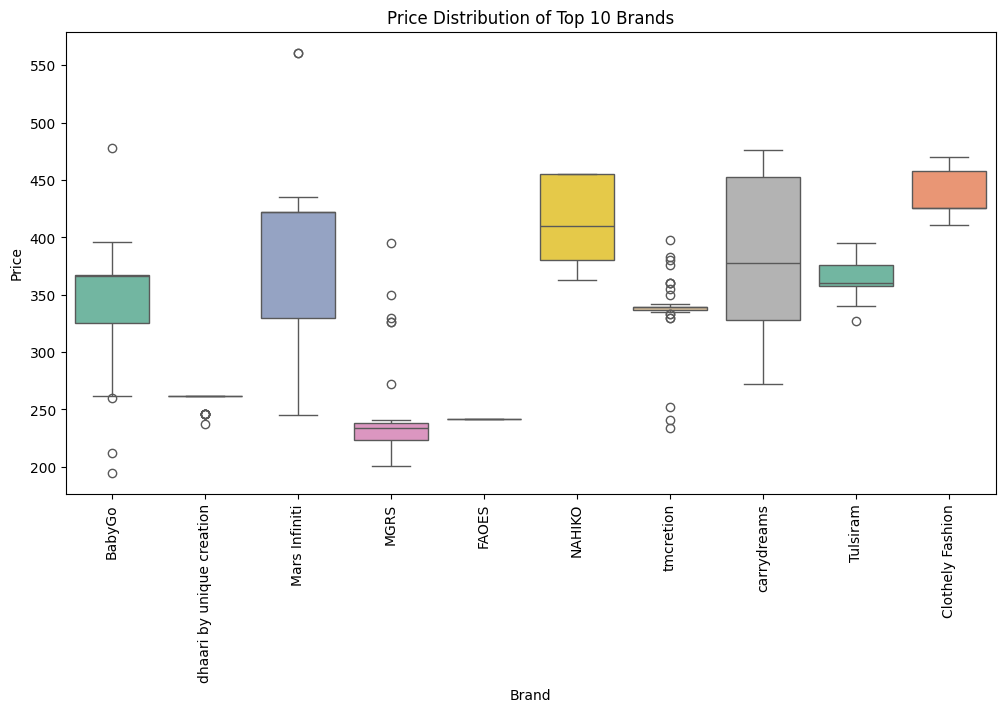

In [89]:
top_brands = df['Brand'].value_counts().nlargest(10).index
df_top = df[df['Brand'].isin(top_brands)]
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df_top, palette='Set2')
plt.title('Price Distribution of Top 10 Brands')
plt.xticks(rotation=90)
plt.show()

* **Clothely Fashion** and **NAHIKO** are premium brands with high, consistent prices, while **MGRS**, **FAOES**, and **dhaari by unique creation** are budget-friendly with low, stable prices.
* Brands like **carrydreams** and **Mars Infiniti** have a wide price range, offering both cheap and expensive products. Brands like **FAOES** have similar prices across all products.
* **Dots** on the plot show outliers—products much cheaper or more expensive than the usual range, like a Mars Infiniti item over 550.
* **Price consistency** varies: NAHIKO’s products are tightly clustered at a high price, while BabyGo has a wider spread in mid-range prices.
* **BabyGo** has broad appeal because it offers mid-range pricing with a mix of cheaper and slightly higher-priced options.


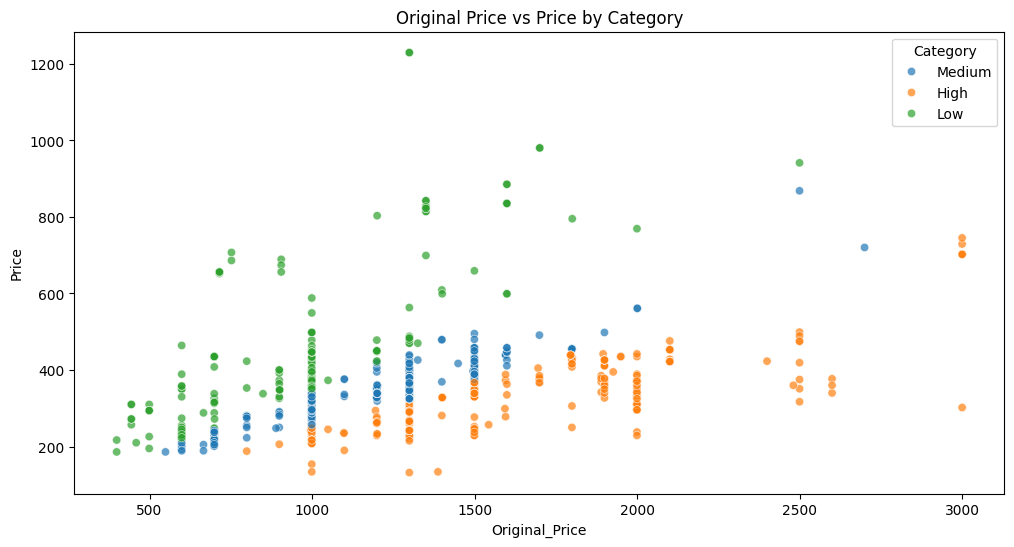

In [63]:
# Price vs Original Price (Numerical vs Numerical)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Original_Price', y='Price', hue='Category', data=df, palette='tab10', alpha=0.7)
plt.title('Original Price vs Price by Category')
plt.show()

* The categories **High, Medium, and Low** represent the level of discount applied.
* **High (orange)** gets the biggest discount, **Medium (blue)** gets a moderate discount, and **Low (green)** gets the smallest discount.
* **High category products** are always the cheapest after discount, even if the original price is high.
* **Low category products** stay close to their original price and are the most expensive after discounts.
* At any original price, you can see **three clear discount tiers**: High at the bottom, Medium in the middle, Low at the top.
* The **discount category matters more than the original price** in determining the final price.


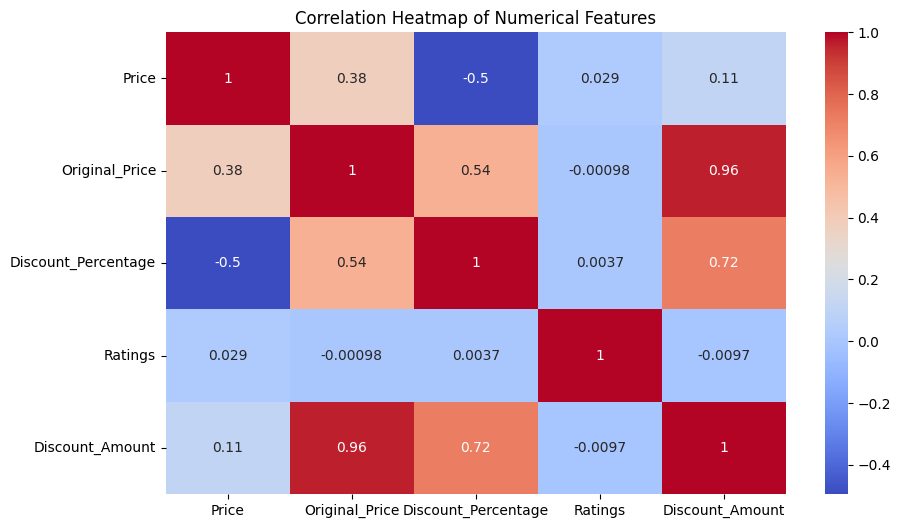

In [64]:
# Correlation Heatmap for Numerical Columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Price', 'Original_Price', 'Discount_Percentage', 'Ratings', 'Discount_Amount']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

* **Discount amount rises with original price**: expensive items get bigger discounts in dollars.
* **Higher discounts lower the final price**: bigger percentage off means cheaper final price.
* **Expensive items often get higher discount percentages**, making them appear like a better deal.
* **Price doesn’t affect customer ratings**: expensive items aren’t rated higher.
* **Discounts don’t affect ratings**: giving bigger discounts doesn’t make customers rate products better; quality matters most.

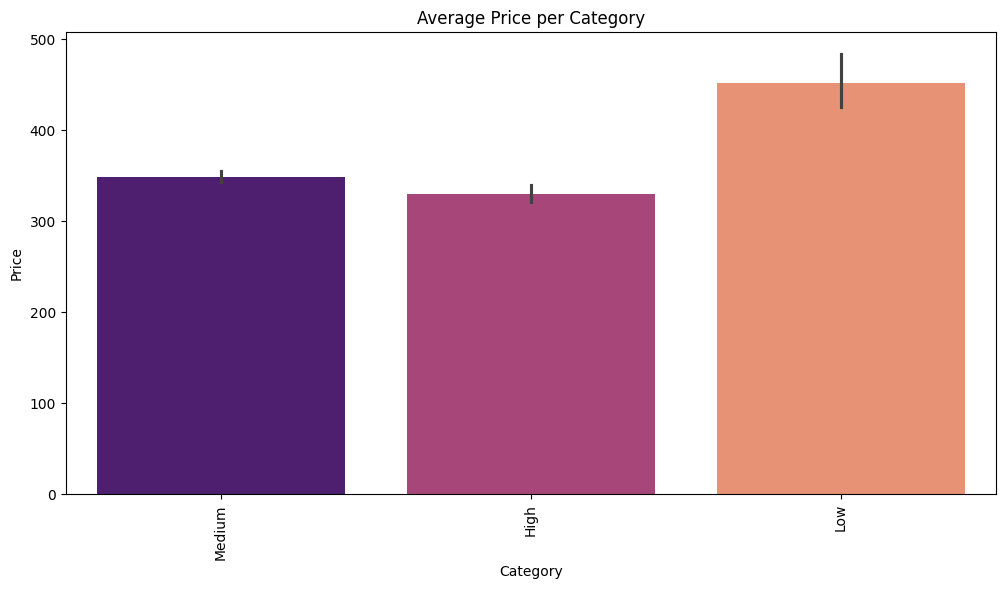

In [65]:
# Category vs Average Price (Categorical vs Numerical)
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Price', data=df, estimator='mean', palette='magma')
plt.title('Average Price per Category')
plt.xticks(rotation=90)
plt.show()


* The category names show **discount level, not final price**: “Low” gets the smallest discount, “High” gets the biggest.
* **Low discount = highest final price**, around 450 on average.
* **High discount = lowest final price**, around 330 on average.
* The three categories create **clear price tiers**, showing how discount level affects final price.
* **Low-discount items** have more price variation, while other categories are more consistent.


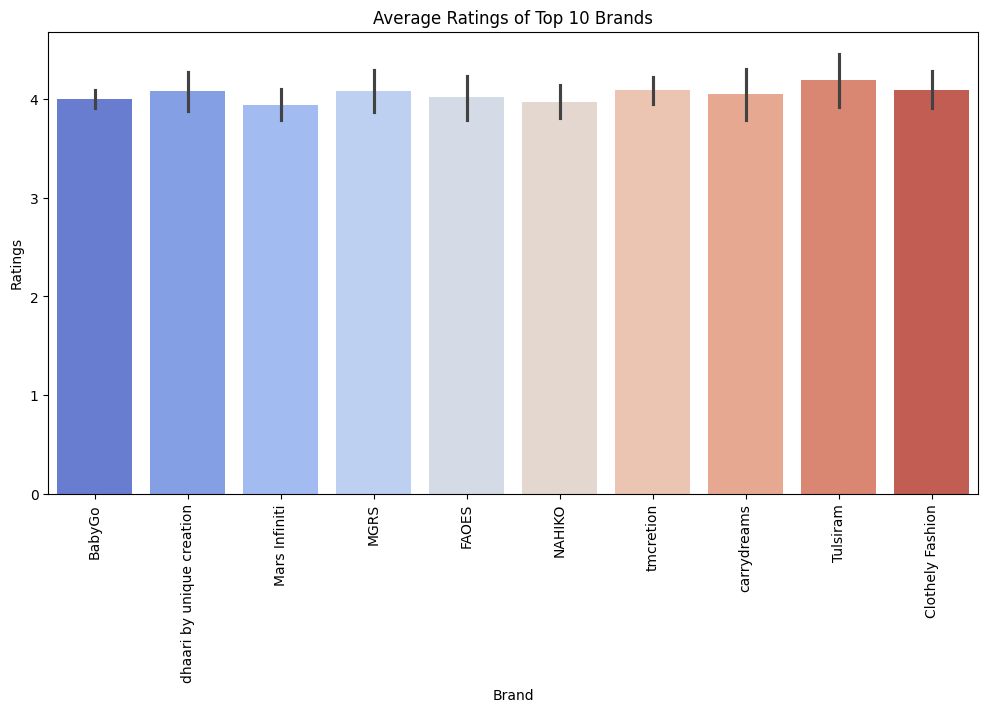

In [90]:
# Brand vs Average Price (Top 10 Brands)
plt.figure(figsize=(12, 6))
top_brands = df['Brand'].value_counts().nlargest(10).index
sns.barplot(x='Brand', y='Ratings', data=df[df['Brand'].isin(top_brands)], estimator='mean', palette='coolwarm')
plt.title('Average Ratings of Top 10 Brands')
plt.xticks(rotation=90)
plt.show()

* All top 10 brands have good ratings, around **4.0**, showing customers like them.
* **Tulsiram** has the highest rating among these brands.
* **Higher price doesn’t mean higher rating**; Clothely Fashion is expensive but not the top-rated.
* Ratings are **consistent** within each brand, with little variation.
* Even the lowest-rated brand, **Mars Infiniti**, still has a strong rating near 4.0, so all top brands perform well.


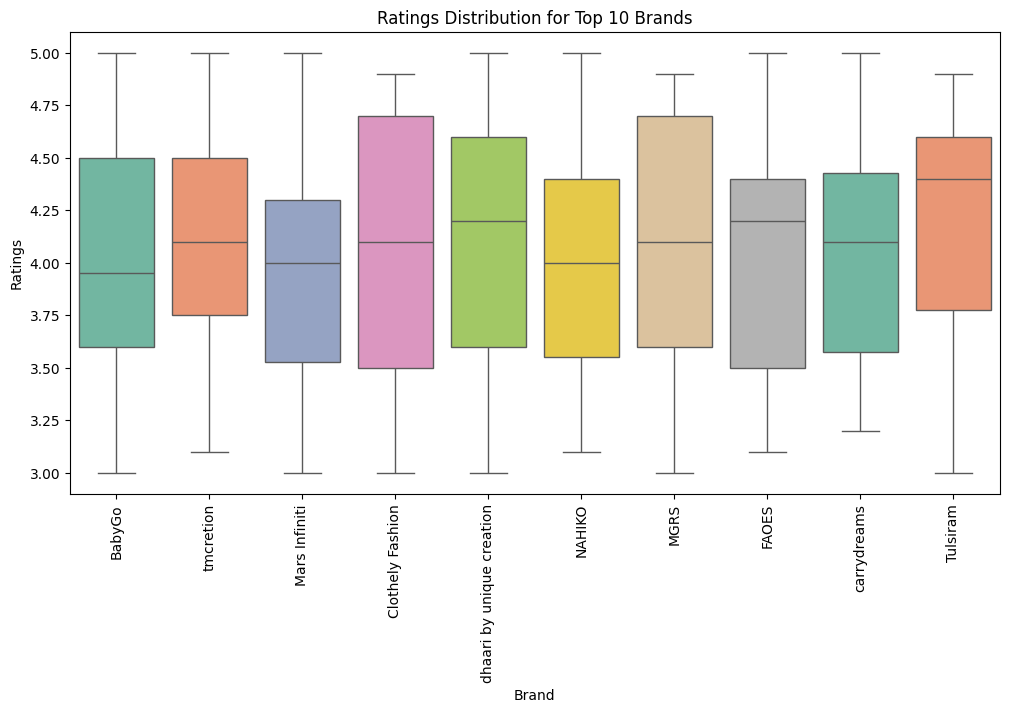

In [92]:
top_10_brands = df['Brand'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Ratings', data=df, order=top_10_brands, palette='Set2')
plt.title('Ratings Distribution for Top 10 Brands')
plt.xticks(rotation=90)
plt.show()

* **Clothely Fashion** has the most mixed ratings, ranging from about 3.5 to 5.0, showing varied customer opinions.
* **Tulsiram** consistently gets high ratings, with most reviews clustered near the top.
* No brand is perfect or hated; all have ratings from average to excellent.
* The **typical rating** for most brands is around **4.0**, showing generally positive customer experiences.
* Brands like **BabyGo** and **NAHIKO** have more consistent ratings, so customer experiences are more predictable.


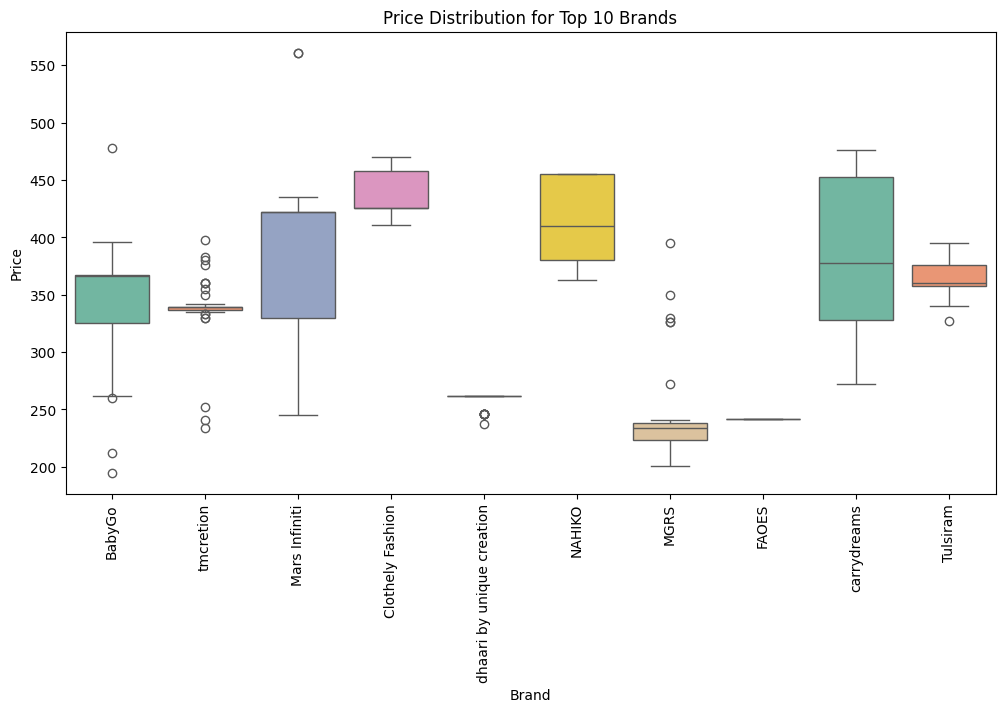

In [68]:
top_10_brands = df['Brand'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df, order=top_10_brands, palette='Set2')
plt.title('Price Distribution for Top 10 Brands')
plt.xticks(rotation=90)
plt.show()

* **Clothely Fashion** and **NAHIKO** are premium brands with high, consistent prices, while **MGRS**, **FAOES**, and **dhaari by unique creation** are budget-friendly with low, stable prices.
* Brands like **carrydreams** and **Mars Infiniti** have a wide price range, while **FAOES** products are priced very similarly.
* **Dots** show outliers—products much cheaper or more expensive than the brand’s usual range, like a Mars Infiniti item over 550.
* **Price consistency** varies: NAHIKO’s products are tightly clustered at high prices, while BabyGo has a wider spread in mid-range prices.
* **BabyGo** appeals to many customers by offering a broad mix of mid-range and some cheaper products.


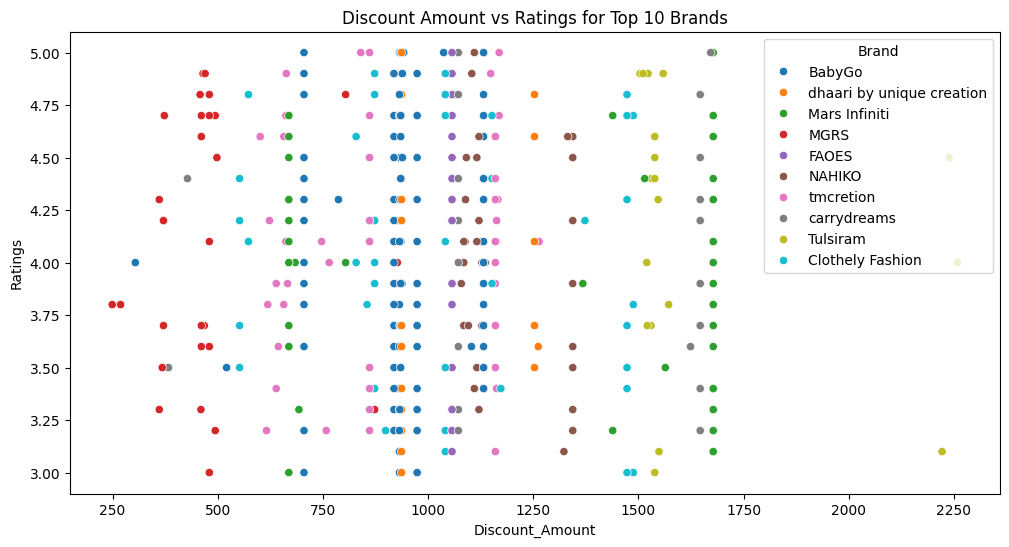

In [93]:
plt.figure(figsize=(12, 6))
top_10_brands = df['Brand'].value_counts().nlargest(10).index
sns.scatterplot(data=df[df['Brand'].isin(top_10_brands)],x='Discount_Amount', y='Ratings', hue='Brand', palette='tab10')
plt.title('Discount Amount vs Ratings for Top 10 Brands')
plt.show()



* **Data issue:** Many products are mislabeled or “Unknown.”
* **Discount strategy:** High discounts = low final price; price doesn’t affect ratings.
* **Brand risk:** BabyGo dominates; premium brands like Clothely Fashion have mixed reviews.
* **Customer favorites:** Dresses, T-shirts, and Tulsiram brand are highly rated.
* **Actionable:** Clean data, focus on top products/brands, and balance discounts.


In [95]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.1,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,T-Shirt,262,1199,78,3.9,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,367,1299,71,3.8,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,T-shirt,193,599,67,3.3,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Unknown,380,1299,70,3.7,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Kurta,389,1499,74,5.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,T-shirt,325,1299,74,4.7,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Pant,366,1299,71,3.3,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Kurta,745,2999,75,4.4,2254,High


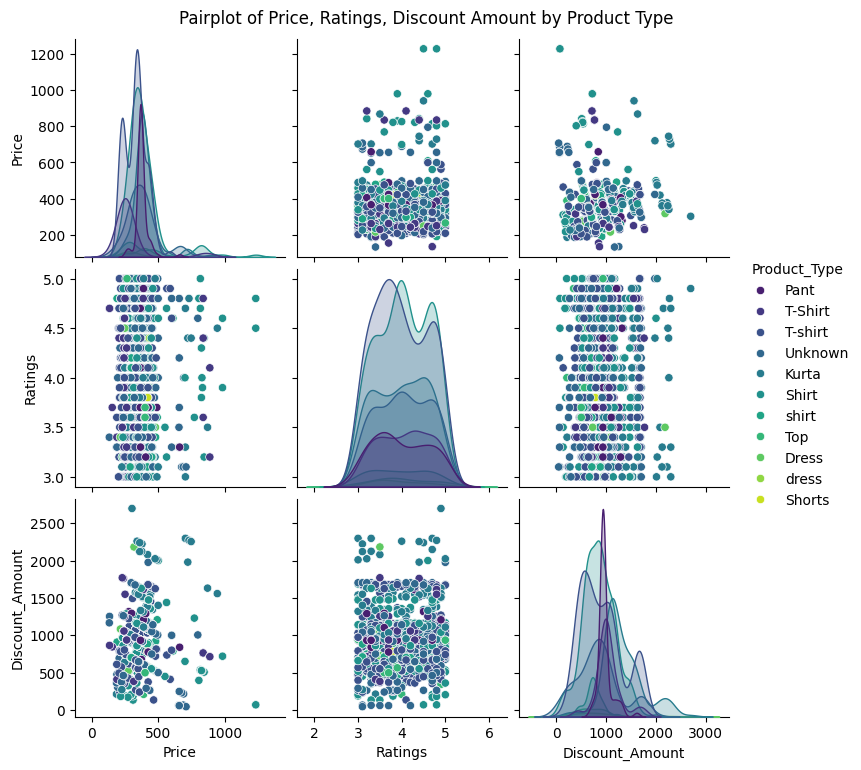

In [97]:

sns.pairplot(df[['Price', 'Ratings', 'Discount_Amount', 'Product_Type']],  hue='Product_Type', palette='viridis')
plt.suptitle('Pairplot of Price, Ratings, Discount Amount by Product Type', y=1.02)
plt.show()


* **Price doesn’t mean better ratings:** Cheap products (under 500) can be rated just as high as expensive ones.
* **Discounts don’t affect ratings:** Bigger discounts don’t make customers happier.
* **Pricing and discounts follow a strategy:** Most prices are under 500; common discounts cluster around 800–1000.
* **Product types mix together:** T-shirts, Kurtas, etc., follow similar pricing and discount patterns—no type-specific rules.
* **Data issues persist:** Inconsistent names like "T-Shirt," "T-shirt," and "shirt" make analysis harder.


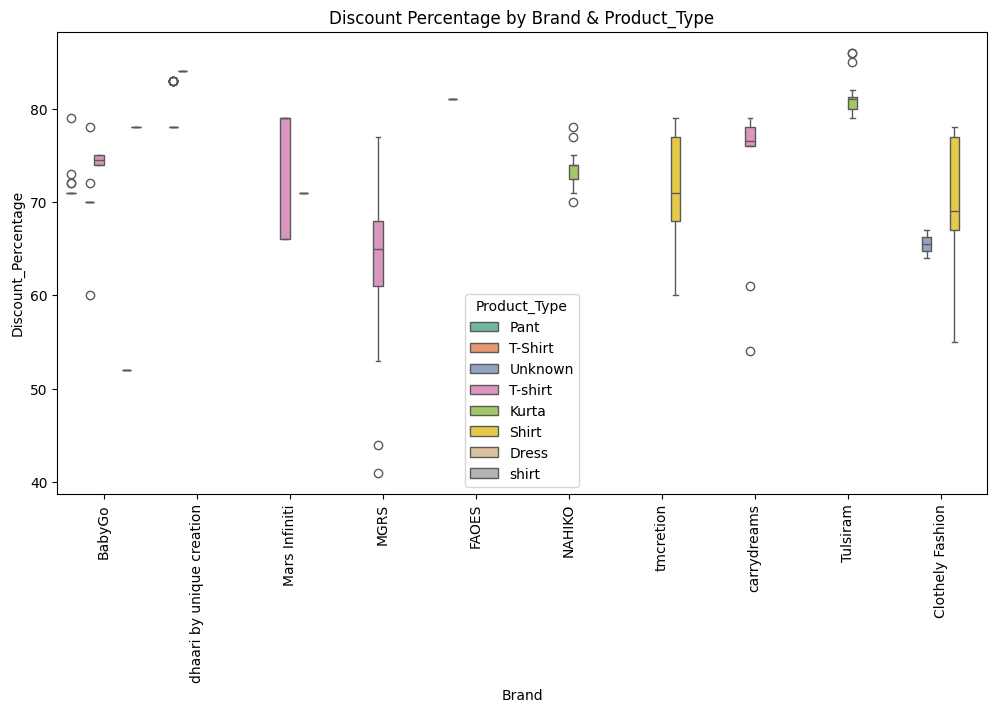

In [98]:
#  Boxplot: Discount Percentage by Brand and Category (Top 10 Brands)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand',y='Discount_Percentage',hue='Product_Type',data=df[df['Brand'].isin(top_10_brands)],palette='Set2')
plt.title('Discount Percentage by Brand & Product_Type')
plt.xticks(rotation=90)
plt.show()

* **Discounts vary by product:** tmcretion discounts Kurtas heavily (70–78%) but Shirts less so, showing product-specific decisions.
* **Some brands are consistent:** BabyGo gives similar high discounts (70–80%) across different products.
* **Targeted aggressive discounts:** Tulsiram discounts Pants at 80%+, Mars Infiniti discounts T-shirts at 70–80%.
* **Premium brands also discount:** Clothely Fashion heavily discounts Shirts, though Dresses have varied discounts.
* **Outliers exist:** Some products, like MGRS T-shirts, have lower discounts (40–45%), showing exceptions to general patterns.


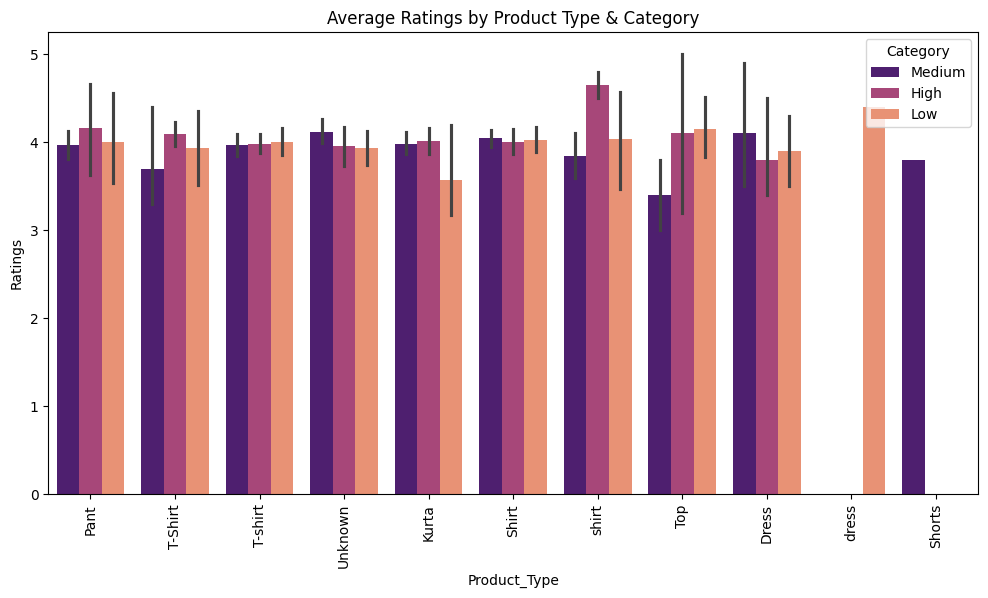

In [75]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Product_Type',y='Ratings',hue='Category', data=df,palette='magma',)
plt.title('Average Ratings by Product Type & Category')
plt.xticks(rotation=90)
plt.show()

* **Low discounts can signal premium quality:** Dresses in the “Low” discount category get the highest ratings, showing customers value them despite higher prices.
* **Discounts don’t improve ratings:** Ratings are driven by product quality, not how much it’s discounted.
* **Some products have fixed discount tiers:** Shorts appear only in Medium, highly-rated Dresses only in Low—showing deliberate sales strategies.
* **Shirts are consistent performers:** Across all types and discount levels, they average around 4.0 stars.
* **Data errors confuse analysis:** “dress” vs. “Dress” have very different ratings; cleaning product names is essential.
